In [18]:
import os
import geopandas as gpd
import requests
import zipfile
import xarray as xr
import xvec
import dask
import json
from pyproj import Transformer


In [2]:
gmw_url = "https://zenodo.org/records/12756047/files/gmw_mng_2020_v4019_gtiff.zip?download=1"
gmw_local_zip = "in/gmw_latest.zip"
gmw_local_dir = "in/gmw_latest"

gmw_local_dir_projected = "in/gmw_latest_1km_nearest_mollweide"

# Create directories and download data

In [ ]:
if not os.path.exists("in/"):
    os.makedirs("in/", exist_ok=True)

if not os.path.exists("out/"):
    os.makedirs("out/", exist_ok=True)

print(f"Downloading Global Mangrove Watch data...")
response = requests.get(gmw_url)

with open(gmw_local_zip, "wb") as f:
    print(f"Writing to {gmw_local_zip}")
    f.write(response.content)

Writing to in/gmw_latest.zip


In [4]:
print(f"Unzipping {gmw_local_zip} to {gmw_local_dir}")
with zipfile.ZipFile(gmw_local_zip, "r") as zip_ref:
    zip_ref.extractall(gmw_local_dir)

Unzipping in/gmw_latest.zip to in/gmw_latest


# Resample/Reproject from 0.0001 degree resolution (WGS84) to 1km resolution (Mollweide)

- To reduce the amount of data we need to crunch through
- Mollweide is an equal area projection, so we can average the data over the grid cells

In [ ]:
gmw_tifs = [f for f in os.listdir(gmw_local_dir) if f.endswith(".tif")]

if not os.path.exists(gmw_local_dir_projected):
    os.makedirs(gmw_local_dir_projected, exist_ok=True)

# Reproject to EPSG:54009 and resample to 1km mollweide
for i, f in enumerate(gmw_tifs):
    print(f"Transforming {f} ({i+1}/{len(gmw_tifs)})")
    os.system(f"gdalwarp -t_srs '+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs' -tr 1000 1000 -r nearest {gmw_local_dir}/{f} {gmw_local_dir_projected}/{f}")
    

# Build VRT

VRT is a virtual raster file that allows us to treat multiple files as a single file, we can use this to convert the data to a single file

In [ ]:
# Build VRT
print("Building VRT...")

# Call bash
os.system(f"bash -c 'gdalbuildvrt {gmw_local_dir_projected}.vrt {gmw_local_dir_projected}/*.tif'")

# Convert to zarr

In [5]:
print("Convert to zarr...")

os.system(f"bash -c 'gdal_translate -of ZARR {gmw_local_dir_projected}.vrt  {gmw_local_dir_projected}.zarr'")

Convert to zarr...
Input file size is 35537, 8901
0...10.

ERROR 6: gmw_latest_1km_nearest_mollweide.zarr, band 1: SetColorTable() not supported for this dataset.


..20...30...40...50...60...70...80...90...100 - done.


0

# Read in the zarr

In [6]:
# Read in zarr
print("Read in zarr")
gmw = xr.open_zarr(f"{gmw_local_dir_projected}.zarr")

# rename X and y to x and y (otherwise we hit some bug in xvec)
gmw = gmw.rename({"X": "x", "Y": "y"})

gmw

Read in zarr


<xarray.Dataset> Size: 1GB
Dimensions:                           (x: 35537, y: 8901)
Coordinates:
  * x                                 (x) float64 284kB -1.76e+07 ... 1.793e+07
  * y                                 (y) float64 71kB 4.223e+06 ... -4.677e+06
Data variables:
    gmw_latest_1km_nearest_mollweide  (y, x) float32 1GB dask.array<chunksize=(256, 256), meta=np.ndarray>

# Do zonal statistics across all states

First we read in geoparquet containing the state boundaries, then we use the zarr data to calculate the zonal statistics for each state

In [56]:
abs_asgs_ste_path = "../../geometries/abs-asgs-edition-3/out/ste2021.parquet"

# Read in ASGS STE
asgs_ste_gdf = gpd.read_parquet(abs_asgs_ste_path)

# Filter out rows without geoms
asgs_ste_gdf = asgs_ste_gdf[asgs_ste_gdf.geometry.notnull()]

asgs_ste_gdf

,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ..."
1,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341..."
2,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ..."
3,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006..."
4,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961..."
5,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443..."
6,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982..."
7,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14..."
8,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748..."


# Plot QLD region and data

<Axes: >

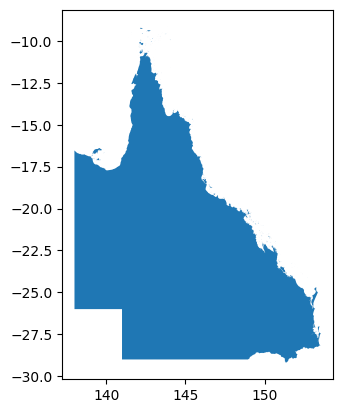

In [9]:
# Plot Queensland
qld_region = asgs_ste_gdf.iloc[[2]]
qld_region.plot()

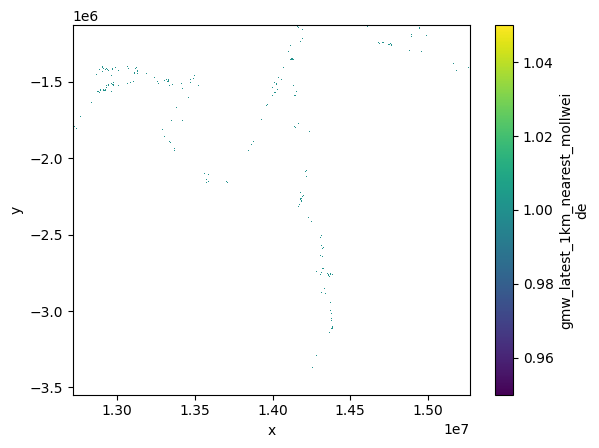

In [30]:
# Take bounds of qld_region and plot
qld_bounds = qld_region.bounds

# Project qld bounds to mollweide
transformer = Transformer.from_crs("epsg:4326", "+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs", always_xy=True)

minx, miny = transformer.transform(qld_bounds.minx.values[0], qld_bounds.miny.values[0])
maxx, maxy = transformer.transform(qld_bounds.maxx.values[0], qld_bounds.maxy.values[0])

qld_subset = gmw["gmw_latest_1km_nearest_mollweide"].sel(x=slice(minx, maxx), y=slice(maxy, miny))

qld_subset.plot()

# Run test zonal statistics on QLD

In [ ]:
qld_gdf = asgs_ste_gdf[asgs_ste_gdf["STE_NAME21"] == "Queensland"]

# Project to mollweide
qld_gdf = qld_gdf.to_crs("+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs")

qld_subset = qld_subset.fillna(0)

aggregated_mean = qld_subset.xvec.zonal_stats(
    qld_gdf.geometry,
    x_coords="x",
    y_coords="y",
    stats="mean",
    name="asgs_ste",
    index=True
).compute()

aggregated_mean

<xarray.DataArray 'gmw_latest_1km_nearest_mollweide' (asgs_ste: 1)> Size: 4B
array([0.00208737], dtype=float32)
Coordinates:
  * asgs_ste  (asgs_ste) object 8B MULTIPOLYGON (((14131578.81687983 -1317963...
    index     (asgs_ste) int64 8B 2
Indexes:
    asgs_ste  GeometryIndex (crs=+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs + ...)
Attributes:
    COLOR_INTERPRETATION:  Palette
    _CRS:                  {'wkt': 'PROJCRS["unknown",BASEGEOGCRS["unknown",D...

# Inspect chunks of zarr

This allows easy parallelisation of compute - we are just using GDALs default chunking here

In [31]:
# Look at chunks in zarr file

gmw.chunks

Frozen({'y': (256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 197), 'x': (256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 209)})

# Do zonal statistics across all states

We also crop data to extent of input geometries

In [57]:
# Crop gmw to asgs_ste_gdf bounds

asgs_ste_gdf_mol = asgs_ste_gdf.to_crs("+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs")

gmw_within_regions = gmw["gmw_latest_1km_nearest_mollweide"].sel(x=slice(asgs_ste_gdf_mol.total_bounds[0], asgs_ste_gdf_mol.total_bounds[2]), y=slice(asgs_ste_gdf_mol.total_bounds[3], asgs_ste_gdf_mol.total_bounds[1]))

gmw_within_regions = gmw_within_regions.fillna(0)

In [58]:
gmw_within_regions

<xarray.DataArray 'gmw_latest_1km_nearest_mollweide' (y: 3549, x: 5927)> Size: 84MB
dask.array<where, shape=(3549, 5927), dtype=float32, chunksize=(256, 256), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float64 47kB 9.568e+06 9.569e+06 ... 1.549e+07 1.549e+07
  * y        (y) float64 28kB -1.129e+06 -1.13e+06 ... -4.676e+06 -4.677e+06
Attributes:
    COLOR_INTERPRETATION:  Palette
    _CRS:                  {'wkt': 'PROJCRS["unknown",BASEGEOGCRS["unknown",D...

## Run on all states

This will calculate the mean pixel value for each state, which represents the proportion of the state that is covered by mangroves (in units of 0.01 degree resolution pixels)

In [59]:
aggregated_mean = gmw_within_regions.xvec.zonal_stats(
    asgs_ste_gdf_mol.geometry,
    x_coords="x",
    y_coords="y",
    stats="mean",
    name="asgs_ste",
    index=True
).compute()

# Inspect results

We can look at the array of results directly

In [60]:
aggregated_mean

<xarray.DataArray 'gmw_latest_1km_nearest_mollweide' (asgs_ste: 9)> Size: 36B
array([1.2080168e-04, 6.5861401e-05, 2.0873693e-03, 8.9078385e-05,
       6.9021928e-04,           nan, 2.6417447e-03, 0.0000000e+00,
       0.0000000e+00], dtype=float32)
Coordinates:
  * asgs_ste  (asgs_ste) object 72B MULTIPOLYGON (((14441516.426549096 -38199...
    index     (asgs_ste) int64 72B 0 1 2 3 4 5 6 7 8
Indexes:
    asgs_ste  GeometryIndex (crs=+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs + ...)
Attributes:
    COLOR_INTERPRETATION:  Palette
    _CRS:                  {'wkt': 'PROJCRS["unknown",BASEGEOGCRS["unknown",D...

We can also pull out specific states

In [61]:
qld_mean = aggregated_mean.values[2]
qld_mean

np.float32(0.0020873693)

# Write to geoparquet

We merge back in metadata from the input geometries, and we also write out each state as GeoJSON

In [62]:
# Convert back to geodataframe - and merge in geometry values
gdf = aggregated_mean.xvec.to_geodataframe()

gdf = gdf.merge(asgs_ste_gdf, left_on="index", right_index=True)

# Drop geometry column
gdf = gdf.drop(columns=["geometry"])

gdf.to_parquet("out/gmw_mean.parquet")

In [63]:
gdf

,asgs_ste,index,gmw_latest_1km_nearest_mollweide,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21
0,"MULTIPOLYGON (((14441516.427 -3819957.457, 144...",0,0.000121,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1
1,"MULTIPOLYGON (((12519103.975 -4695043.639, 125...",1,0.000066,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2
2,"MULTIPOLYGON (((14131578.817 -1317963.866, 141...",2,0.002087,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3
3,"MULTIPOLYGON (((12152496.641 -4571711.755, 121...",3,0.000089,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4
4,"MULTIPOLYGON (((10423149.471 -4245115.082, 104...",4,0.000690,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5
5,"MULTIPOLYGON (((12165698.77 -4901977.881, 1216...",5,NaN,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6
6,"MULTIPOLYGON (((13183253.847 -1345641.647, 131...",6,0.002642,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7
7,"POLYGON ((13184753.608 -4241452.547, 13189035....",7,0.000000,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8
8,"MULTIPOLYGON (((15480461.098 -3541561.652, 154...",8,0.000000,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9


In [64]:
# Write out GeoJSON for each row

features = gdf.iterfeatures()

for i, feature in enumerate(features):
    with open(f"out/{i}.geojson", "w") as f:
        json.dump(feature, f)


# Read in geoparquet to calculate (rough) area of each state

We are expecting

> A total of 0.4 million hectares (45%) is found in Queensland and 0.3 million hectares (39%) are in the Northern Territory

From https://www.agriculture.gov.au/abares/forestsaustralia/australias-forests/profiles/mangrove-2019

The calculation is "rough", as we are using the proportion of pixels that are mangroves in each state to calculate the area of mangroves in each state. This is not perfect, as the area of each pixel is not uniform, and the mangroves are not evenly distributed within each pixel.

In [65]:
# Read in geoparquet to calculate (rough) area of each state
import geopandas as gpd

gmw_mean = gpd.read_parquet("out/gmw_mean.parquet")

# Multiply columns "AREASQKM21" and "gmw_latest_1km_nearest_mollweide" to get rough area of mangroves in each state
gmw_mean["mangrove_area"] = gmw_mean["AREASQKM21"] * gmw_mean["gmw_latest_1km_nearest_mollweide"]

gmw_mean

,asgs_ste,index,gmw_latest_1km_nearest_mollweide,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,mangrove_area
0,"MULTIPOLYGON (((14441516.427 -3819957.457, 144...",0,0.000121,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,96.737700
1,"MULTIPOLYGON (((12519103.975 -4695043.639, 125...",1,0.000066,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,14.983222
2,"MULTIPOLYGON (((14131578.817 -1317963.866, 141...",2,0.002087,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,3611.506339
3,"MULTIPOLYGON (((12152496.641 -4571711.755, 121...",3,0.000089,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,87.673745
4,"MULTIPOLYGON (((10423149.471 -4245115.082, 104...",4,0.000690,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,1743.930462
5,"MULTIPOLYGON (((12165698.77 -4901977.881, 1216...",5,NaN,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,NaN
6,"MULTIPOLYGON (((13183253.847 -1345641.647, 131...",6,0.002642,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,3561.427124
7,"POLYGON ((13184753.608 -4241452.547, 13189035....",7,0.000000,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,0.000000
8,"MULTIPOLYGON (((15480461.098 -3541561.652, 154...",8,0.000000,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,0.000000


<Axes: >

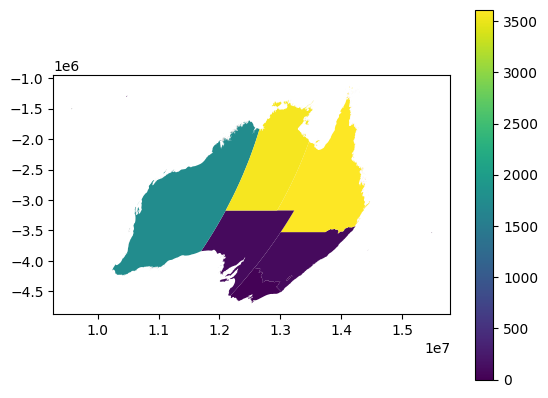

In [66]:
# Plot
gmw_mean.plot(column="mangrove_area", legend=True)